In [1]:
import numpy as np 
import pandas as pd
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.spline as spline
import src.analysis.plots as plots
import src.statistics.combination as comb

In [2]:
ROOT = Path('results')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [3]:
scale_cut = [0.3, 3]
data = np.load(ROOT/f'merged_res_norm_{scale_cut[0]}_{scale_cut[1]}.npz')
names = ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']
print(data.files)

['1/npz_cross_z', '1/npz_cross', '1/npz_cross_err', '1/npz_bs_z', '1/npz_bs', '1/npz_bs_err', '1/npz_bs_bp_z', '1/npz_bs_bp', '1/npz_bs_bp_err', '1/npz_bs_bp_mag_z', '1/npz_bs_bp_mag', '1/npz_bs_bp_mag_err', '2/npz_cross_z', '2/npz_cross', '2/npz_cross_err', '2/npz_bs_z', '2/npz_bs', '2/npz_bs_err', '2/npz_bs_bp_z', '2/npz_bs_bp', '2/npz_bs_bp_err', '2/npz_bs_bp_mag_z', '2/npz_bs_bp_mag', '2/npz_bs_bp_mag_err', '3/npz_cross_z', '3/npz_cross', '3/npz_cross_err', '3/npz_bs_z', '3/npz_bs', '3/npz_bs_err', '3/npz_bs_bp_z', '3/npz_bs_bp', '3/npz_bs_bp_err', '3/npz_bs_bp_mag_z', '3/npz_bs_bp_mag', '3/npz_bs_bp_mag_err', '4/npz_cross_z', '4/npz_cross', '4/npz_cross_err', '4/npz_bs_z', '4/npz_bs', '4/npz_bs_err', '4/npz_bs_bp_z', '4/npz_bs_bp', '4/npz_bs_bp_err', '4/npz_bs_bp_mag_z', '4/npz_bs_bp_mag', '4/npz_bs_bp_mag_err']


In [4]:
tomo = 1
z = [data[f'{tomo}/{name}_z'] for name in names]
npz = [data[f'{tomo}/{name}'] for name in names]
npz_err = [data[f'{tomo}/{name}_err'] for name in names]

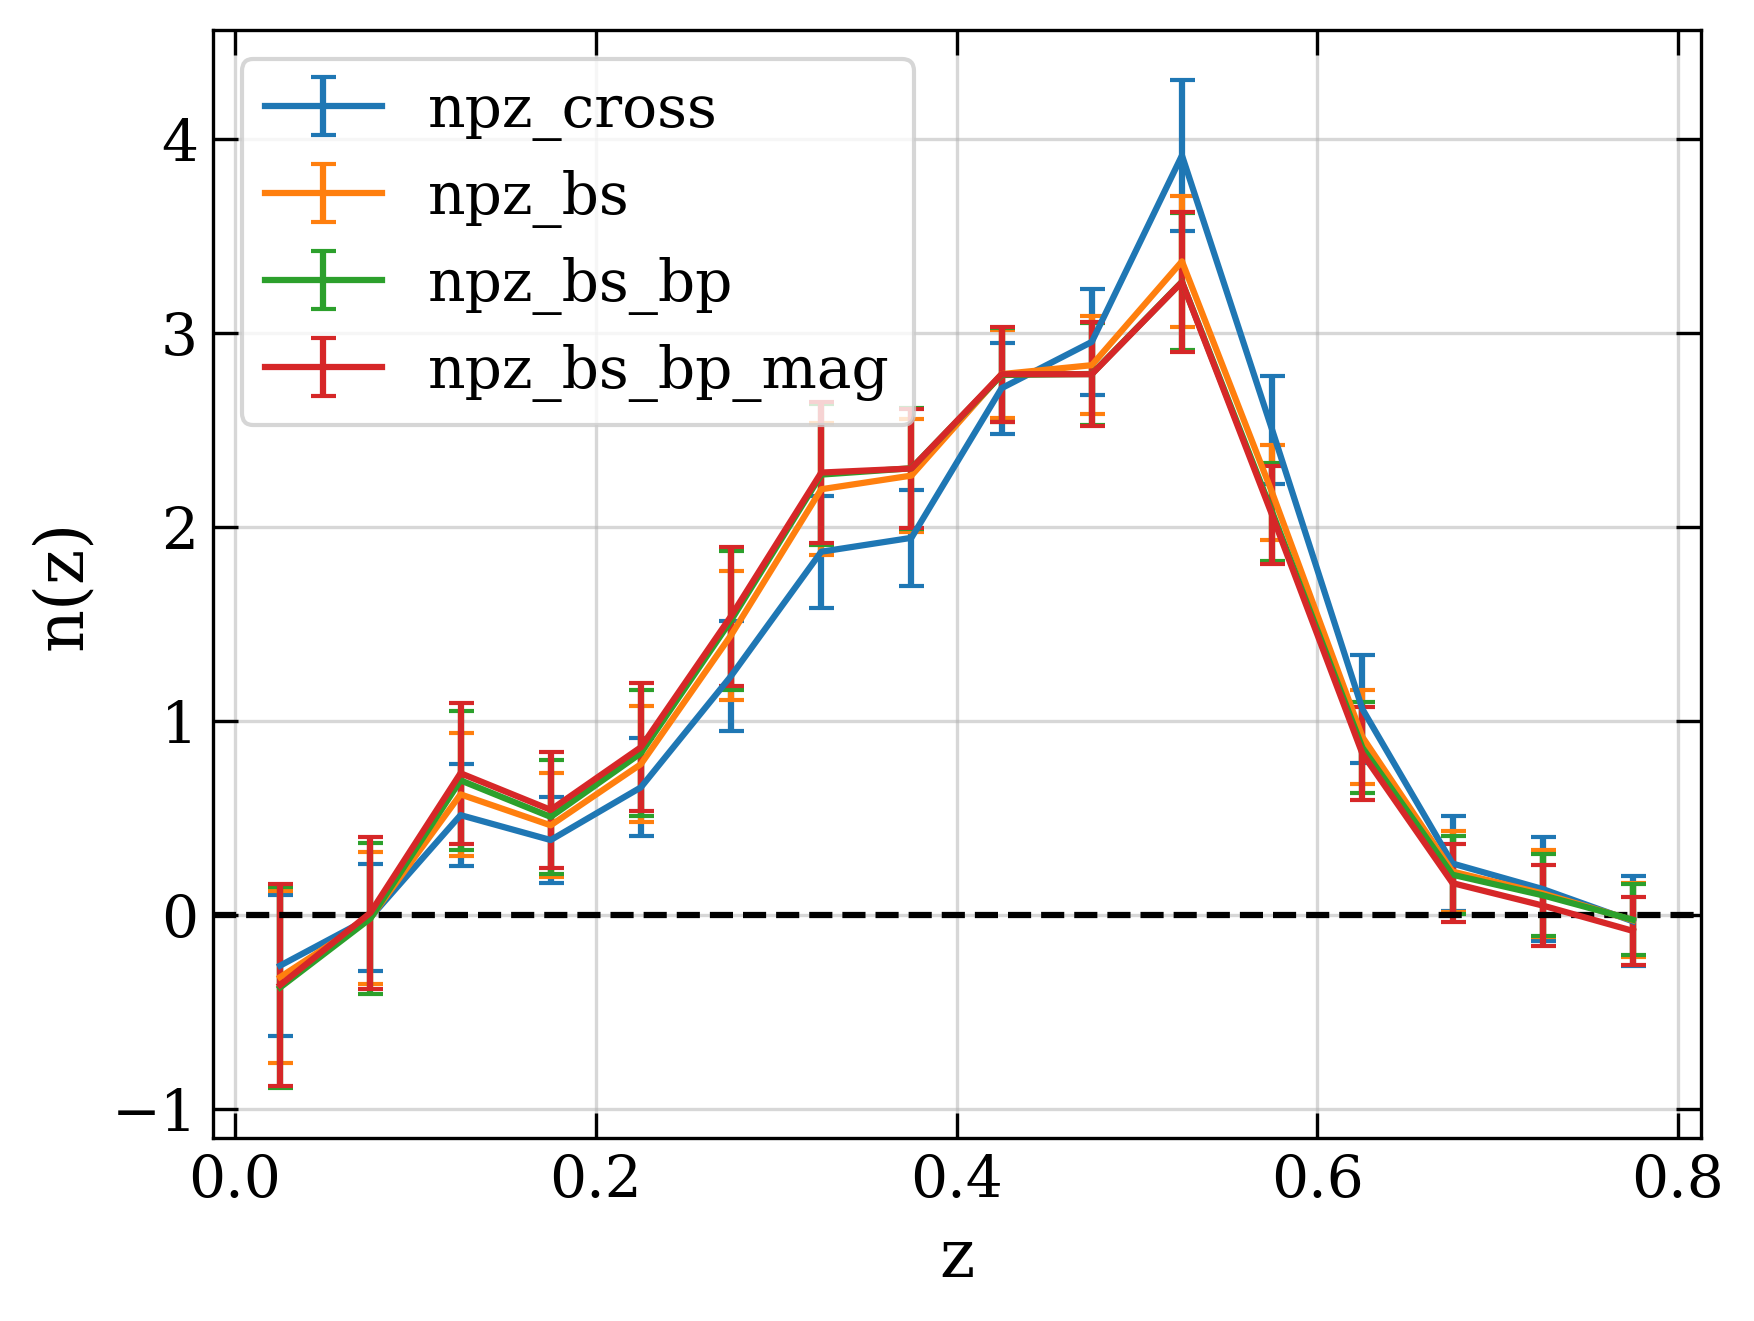

In [5]:
for i, name in enumerate(names):
    plt.errorbar(z[i], npz[i], npz_err[i], capsize=3, label=name)
plt.legend()
plt.grid(True)
plt.ylabel('n(z)')
plt.xlabel('z')
plt.axhline(0, color='black', linestyle='--')

9.743397748531205
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines/spl_npz_bs_bp_1.nc
  - Metadata: results/splines/spl_npz_bs_bp_1_meta.pkl
  - Posterior samples: 6400


/tmp/ipykernel_1438233/3594269305.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


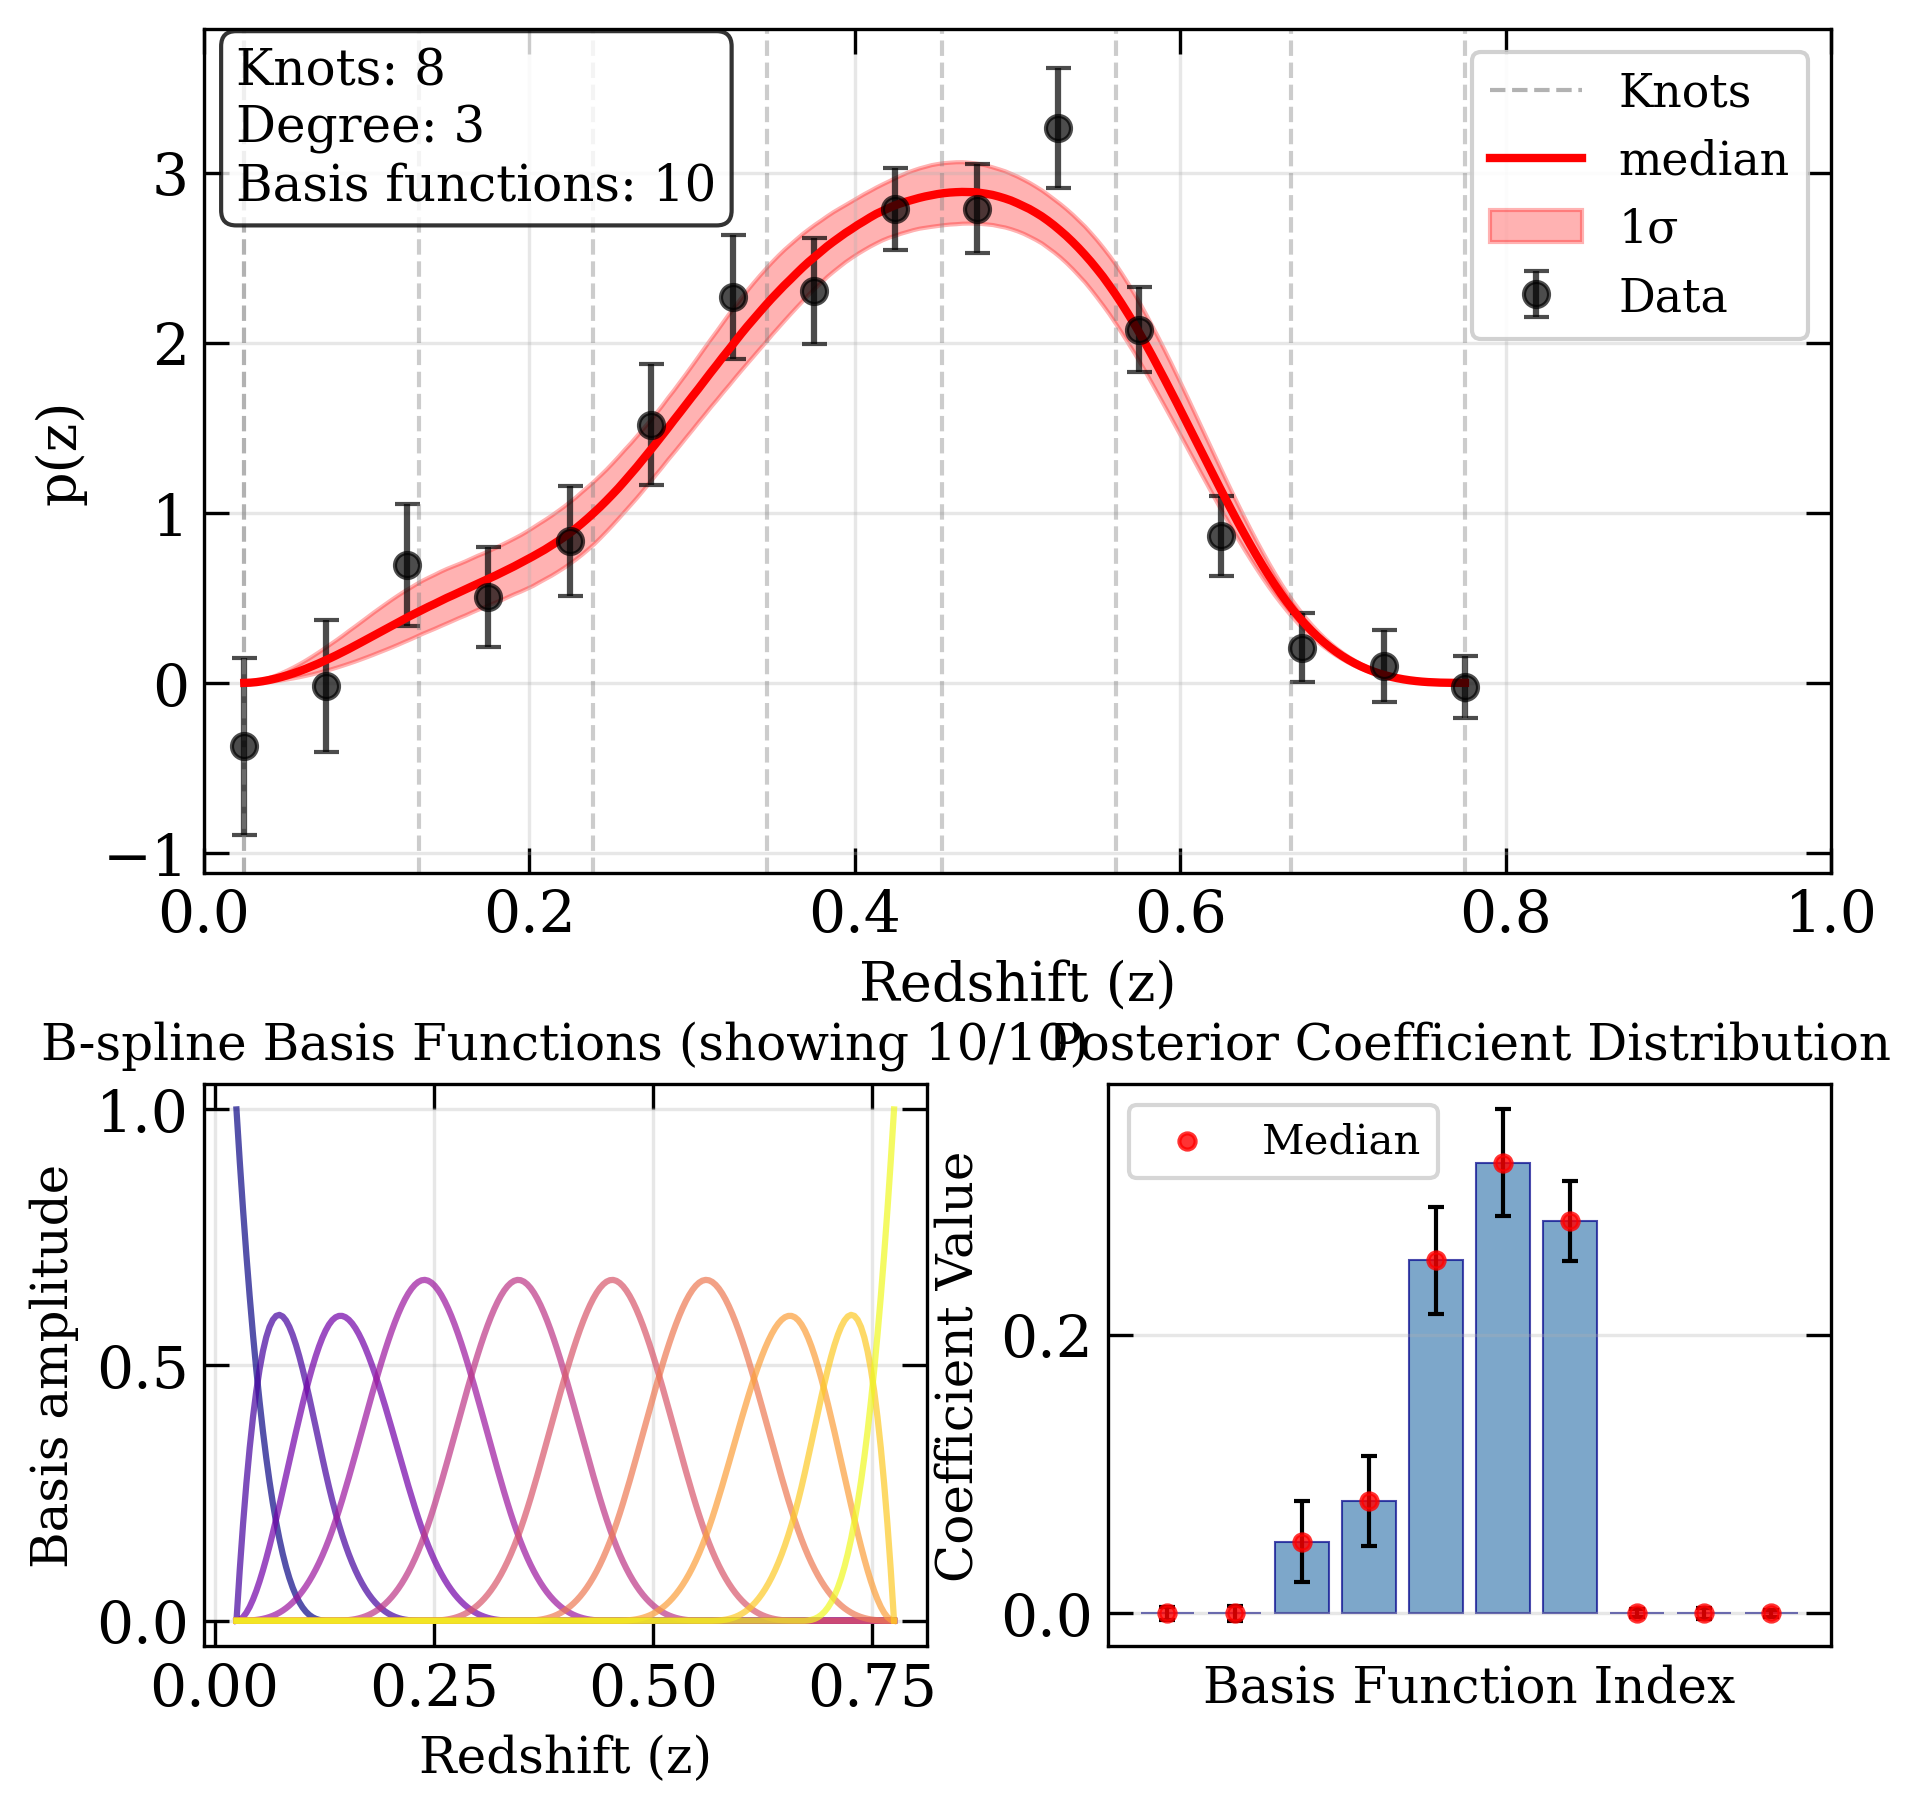

In [19]:
spl_study = spline.BayesianBSpline.from_saved_model(f'results/splines/spl_npz_bs_bp_1')
show_knots = True
z_eval = np.linspace(np.array(z).min(), np.array(z).max(), 200)
n_eval_points=200
nz_samples = spl_study.get_samples(z_eval=z_eval, n_eval_points=n_eval_points)
basis_eval = spl_study._create_evaluation_basis(z_eval)

nz_median = np.percentile(nz_samples, 50, axis=0)
nz_mean = np.mean(nz_samples, axis=0)
nz_std = np.std(nz_samples, axis=0)
nz_lower = np.percentile(nz_samples, 16, axis=0)
nz_upper = np.percentile(nz_samples, 84, axis=0)

fig = plt.figure(figsize=(7,7))
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1], hspace=0.3, wspace=0.25)
ax_main = fig.add_subplot(gs[0, :])

info_text = f'Knots: {spl_study.n_knots}\nDegree: {spl_study.degree}\nBasis functions: {spl_study.n_basis}'

ax_main.errorbar(
    spl_study.zv, 
    spl_study.nz, 
    yerr=spl_study.nz_err,
    fmt='o', 
    color='black',
    alpha=0.7,
    capsize=3, 
    capthick=1, 
    label='Data'
    )

if show_knots:
    knot_positions = spl_study.knots[spl_study.degree:-spl_study.degree]
    for i, knot in enumerate(knot_positions):
        alpha_val = 0.6 if i == 0 else 0.4
        label_val = 'Knots' if i == 0 else None
        ax_main.axvline(knot, color='gray', linestyle='--', alpha=alpha_val, 
                    linewidth=1, label=label_val)

ax_main.set_xlabel('Redshift (z)', fontsize=13)
ax_main.set_ylabel('p(z)', fontsize=13)
ax_main.grid(True, alpha=0.3)

ax_main.plot(
    z_eval, 
    nz_median, 
    color='red', 
    alpha=1,
    linewidth=2, 
    label='median'
    )
ax_main.fill_between(
    z_eval, 
    nz_lower, 
    nz_upper, 
    color='red', 
    alpha=0.3, 
    label='1σ'
    )

ax_main.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax_main.text(
    0.02, 
    0.98, 
    info_text, 
    transform=ax_main.transAxes,
    verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), 
    fontsize=12
    )
ax_main.set_xlim(0., 1.)

ax_basis = fig.add_subplot(gs[1, 0])
n_show = spl_study.n_basis
indices = np.linspace(1, spl_study.n_basis, n_show, dtype=int)
colors = plt.cm.plasma(np.linspace(0, 1, n_show))

for i, idx in enumerate(indices):
    basis_func = basis_eval[:, i]
    ax_basis.plot(
        z_eval, 
        basis_func, 
        color=colors[i], 
        alpha=0.7, 
        linewidth=1.5, 
        label=f'B_{idx}' if n_show <= 6 else None
        )

ax_basis.set_xlabel('Redshift (z)', fontsize=12)
ax_basis.set_ylabel('Basis amplitude', fontsize=12)
ax_basis.set_title(f'B-spline Basis Functions (showing {n_show}/{spl_study.n_basis})', fontsize=12)
ax_basis.grid(True, alpha=0.3)
if n_show <= 6:
    ax_basis.legend(fontsize=9, ncol=2)

# Coefficient histogram (bottom right)
ax_coeff = fig.add_subplot(gs[1, 1])
coeff_means = np.mean(spl_study.coeffs_samples, axis=0)
coeff_stds = np.std(spl_study.coeffs_samples, axis=0)
coeff_medians = np.median(spl_study.coeffs_samples, axis=0)
x_pos = np.arange(spl_study.n_basis)

ax_coeff.bar(x_pos, coeff_medians, yerr=coeff_stds, 
                    capsize=2, alpha=0.7, color='steelblue',
                    edgecolor='darkblue', linewidth=0.5, error_kw={'linewidth': 1})

ax_coeff.scatter(x_pos, coeff_medians, color='red', s=15, alpha=0.8, 
                zorder=3, label='Median')

ax_coeff.set_xlabel('Basis Function Index', fontsize=12)
ax_coeff.set_ylabel('Coefficient Value', fontsize=12)
ax_coeff.set_title('Posterior Coefficient Distribution', fontsize=12)
ax_coeff.grid(True, alpha=0.3, axis='y')
ax_coeff.legend(fontsize=10)
ax_coeff.set_xticks([])

plt.tight_layout()

9.678092751392631
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_cross_1.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_cross_1_meta.pkl
  - Posterior samples: 6400
9.708332331547883
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_bs_1.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_bs_1_meta.pkl
  - Posterior samples: 6400
9.743397748531205
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_bs_bp_1.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_bs_bp_1_meta.pkl
  - Posterior samples: 6400
9.805011785174113
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_bs_bp_mag_1.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_bs_bp_mag_1_meta.pkl
  - Posterior samples: 6400


Expectation
16th, 50th, 84th percentiles: [0.44053002 0.

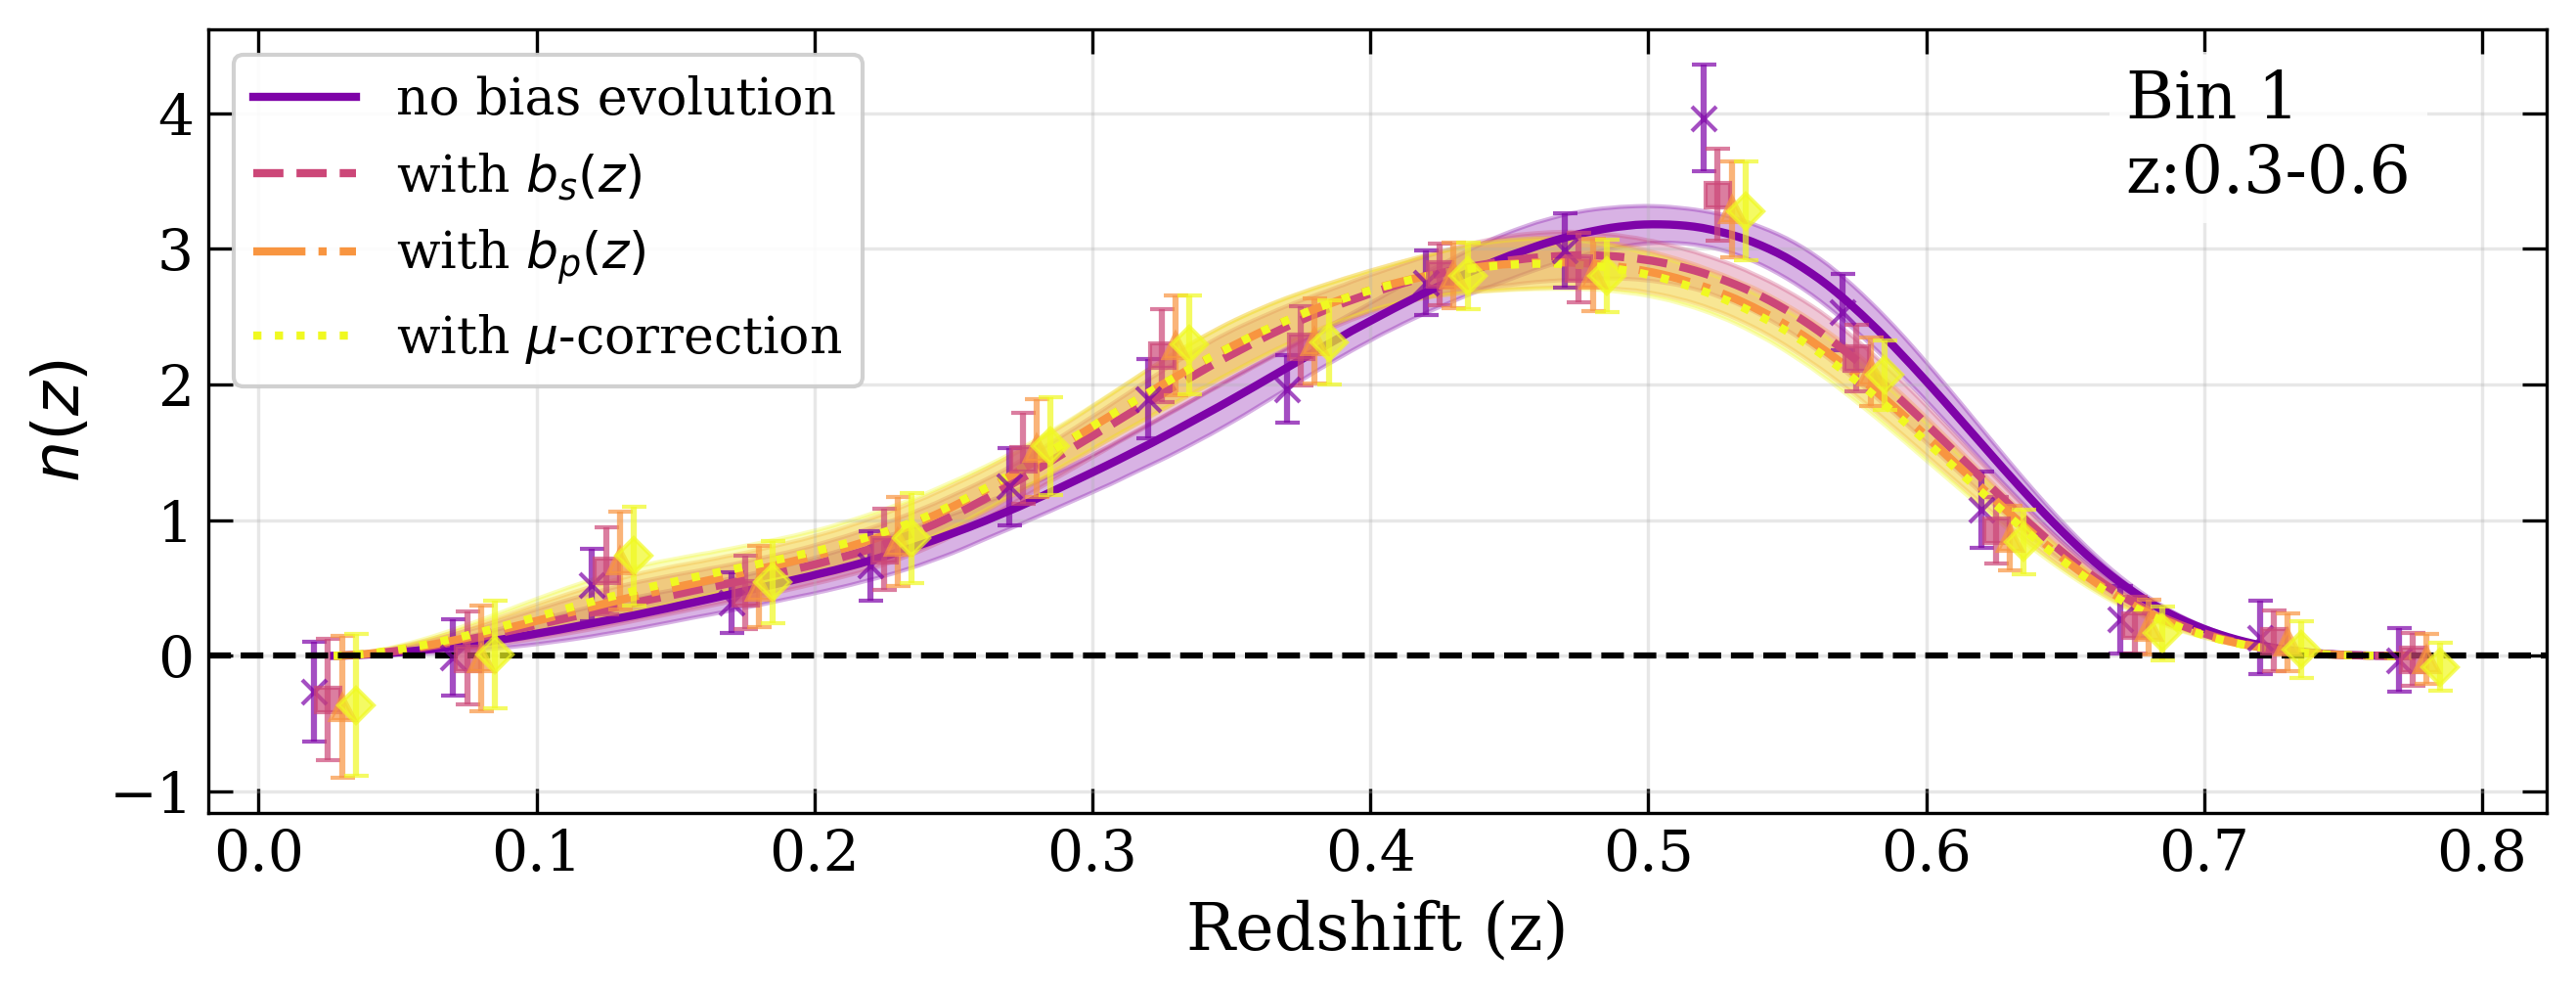

9.731417977507881
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_cross_2.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_cross_2_meta.pkl
  - Posterior samples: 6400
10.14572028339834
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_bs_2.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_bs_2_meta.pkl
  - Posterior samples: 6400
10.10091691106627
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_bs_bp_2.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_bs_bp_2_meta.pkl
  - Posterior samples: 6400
10.156009665505572
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_bs_bp_mag_2.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_bs_bp_mag_2_meta.pkl
  - Posterior samples: 6400


Expectation
16th, 50th, 84th percentiles: [0.72534103 0

In [ ]:
s_data = {}
expect = {}
show_knots = False
z_all = np.linspace(0, 3, 1000)
names = ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']
name_to_label = {
    'npz_cross': 'no bias evolution',
    'npz_bs': r'with $b_s(z)$',
    'npz_bs_bp': r'with $b_p(z)$',
    'npz_bs_bp_mag': r'with $\mu$-correction'
}

for tomo in [1, 2, 3, 4]:
    spline_dict = {name : spline.BayesianBSpline.from_saved_model(f'results/splines_{scale_cut[0]}_{scale_cut[1]}_newbounds/spl_{name}_{tomo}') for name in names}

    with pm.make_plot(f'nz_spline_tomo{tomo}', figsize=(9, 3.6), show=True) as (fig, ax_main):
        cmap = plt.get_cmap('plasma')
        markers = ['x', 's', '^', 'D']
        linestyles = ['-', '--', '-.', ':']

        for ind, name in enumerate(names):
            spl_study = spline_dict[name]

            mask = (z_all <= spl_study.zv.max()) & (z_all >= spl_study.zv.min())
            z_eval = z_all[mask]

            n_eval_points=200
            nz_samples = spl_study.get_samples(z_eval=z_eval, n_eval_points=n_eval_points)
            basis_eval = spl_study._create_evaluation_basis(z_eval)
            
            nz_median = np.percentile(nz_samples, 50, axis=0)
            norm_median = simpson(nz_median, z_eval)
            nz_samples_norm = nz_samples / simpson(nz_samples, z_eval, axis=1)[:, None]
            
            nz_median = np.percentile(nz_samples_norm, 50, axis=0)
            nz_mean = np.mean(nz_samples_norm, axis=0)
            nz_std = np.std(nz_samples_norm, axis=0)
            nz_lower = np.percentile(nz_samples_norm, 16, axis=0)
            nz_upper = np.percentile(nz_samples_norm, 84, axis=0)

            color = cmap((ind+1)/len(names))
            
            nz_median_all = np.zeros(len(z_all))
            nz_mean_all = np.zeros(len(z_all))
            nz_mean_all[mask] = nz_mean
            nz_median_all[mask] = nz_median
            nz_lower_all = np.zeros(len(z_all))
            nz_lower_all[mask] = nz_lower
            nz_upper_all = np.zeros(len(z_all))
            nz_upper_all[mask] = nz_upper
            
            s_data[f'z'] = z_all
            if (name == 'npz_bs_bp') or (name == 'npz_bs_bp_mag'):
                if 'mag' in name:
                    add = '_mu'
                else:
                    add = ''
                s_data[f'{tomo}/nz_median{add}'] = nz_median_all
                s_data[f'{tomo}/nz_mean{add}'] = nz_mean_all
                s_data[f'{tomo}/nz_lower{add}'] = nz_lower_all
                s_data[f'{tomo}/nz_upper{add}'] = nz_upper_all

            ax_main.errorbar(
                spl_study.zv+(0.005*(ind-1)), 
                spl_study.nz / norm_median, 
                yerr=spl_study.nz_err / norm_median,
                fmt=markers[ind], 
                color=color,
                alpha=0.7,
                capsize=3, 
                capthick=1, 
                )
            ax_main.plot(
                z_eval, 
                nz_median, 
                color=color, 
                alpha=1,
                linewidth=2, 
                linestyle=linestyles[ind],
                label=name_to_label[name]
                )
            ax_main.fill_between(
                z_eval, 
                nz_lower, 
                nz_upper, 
                color=color, 
                alpha=0.3, 
                )
            print('\n')
            print('Expectation')
            expect_samples = [np.trapezoid(nzsn * z_eval, z_eval) for nzsn in nz_samples_norm]
            percentiles = np.percentile(expect_samples, [16, 50, 84])
            print(f'16th, 50th, 84th percentiles: {percentiles}')
            expect_nz = np.trapezoid(nz_mean * z_eval, z_eval)
            print(f'Expectation from mean n(z): {expect_nz}') 
            print('\n')
            expect[f'{tomo}/{name}'] = percentiles
            expect[f'{tomo}/{name}_mean'] = expect_nz
                        
        ax_main.legend(fontsize=12.5, loc='upper left', framealpha=0.9)
        ax_main.text(
            0.82, 
            0.95, 
            f'Bin {tomo}\nz:{0.3*tomo:.1f}-{0.3*(tomo+1):.1f}', 
            transform=ax_main.transAxes,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
            fontsize=16
        )

        if show_knots:
            knot_positions = spl_study.knots[spl_study.degree:-spl_study.degree]
            for i, knot in enumerate(knot_positions):
                alpha_val = 0.6 if i == 0 else 0.4
                label_val = 'Knots' if i == 0 else None
                ax_main.axvline(knot, color='gray', linestyle='--', alpha=alpha_val, 
                            linewidth=1, label=label_val)

        ax_main.set_xlabel('Redshift (z)', fontsize=16)
        ax_main.set_ylabel(r'$n(z)$', fontsize=16)
        ax_main.axhline(0, color='black', linestyle='--')
        ax_main.grid(True, alpha=0.3)

In [18]:
np.savez(ROOT / f'distributions_{scale_cut[0]}_{scale_cut[1]}_v2.npz', **s_data)
np.savez(ROOT / f'expectations_{scale_cut[0]}_{scale_cut[1]}_v2.npz', **expect)

In [8]:
tomo_bin_dnnz = np.loadtxt('pz/data/tomographic_binning_dnnz.dat')
mids = tomo_bin_dnnz[:, 0]

In [9]:
splines_dict = {
    name : 
        {
            tomo : 
                spline.BayesianBSpline.from_saved_model(f'results/splines_{scale_cut[0]}_{scale_cut[1]}_newbounds/spl_{name}_{tomo}') 
                for tomo in [1,2,3,4]
            } 
        for name in names
        }

bounds = {
    '1' : (0, 0.9),
    '2' : (0.3, 1.3),
    '3' : (0.3, 2.1),
    '4' : (0.7, 2.1)
}
do_bounds = True
if not do_bounds:
    bounds = {
        f'{i}' : (0, 3) for i in range(1, 5)
    }

9.678092751392631
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_cross_1.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_cross_1_meta.pkl
  - Posterior samples: 6400
9.731417977507881
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_cross_2.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_cross_2_meta.pkl
  - Posterior samples: 6400
10.378122517276228
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_cross_3.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_cross_3_meta.pkl
  - Posterior samples: 6400
9.979839388471511
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_newbounds/spl_npz_cross_4.nc
  - Metadata: results/splines_0.3_3_newbounds/spl_npz_cross_4_meta.pkl
  - Posterior samples: 6400
9.708332331547883
PyMC model recreated from parameters
Mode

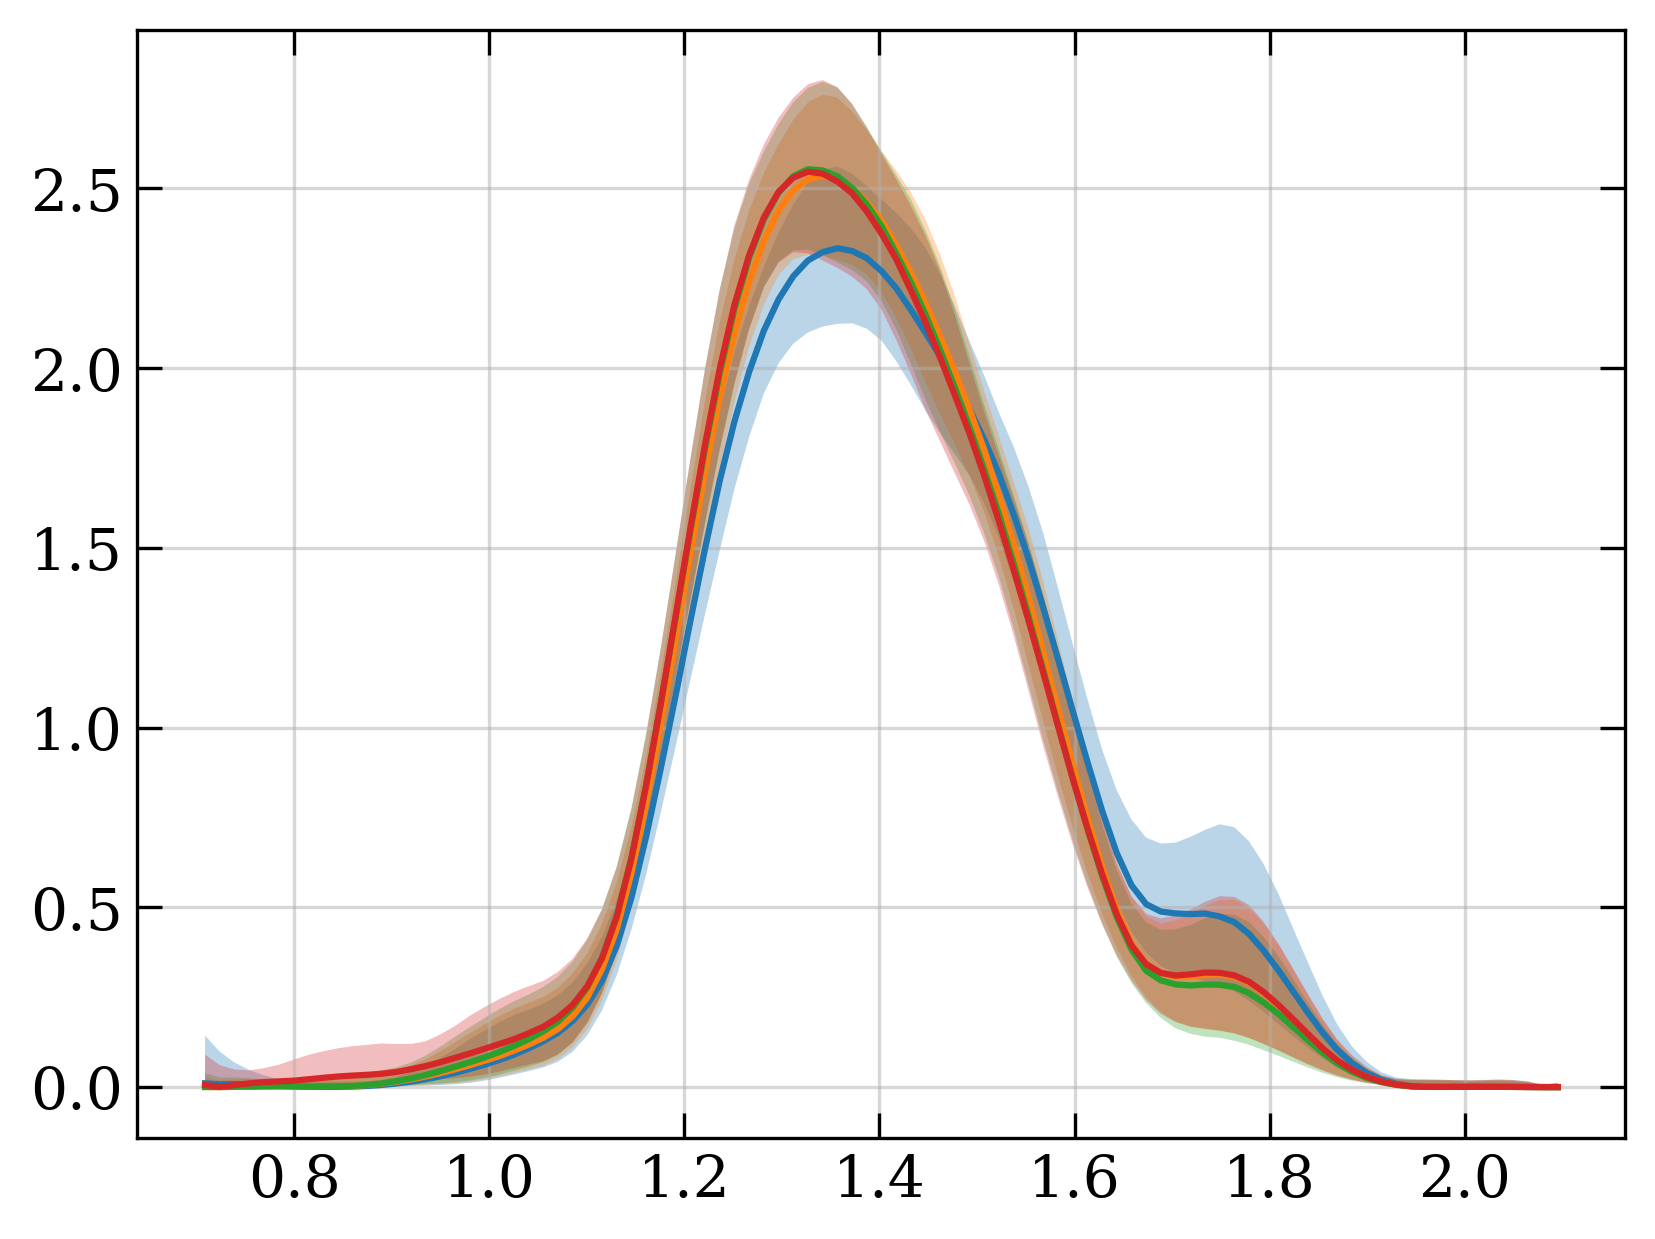

In [11]:
# save to file the sample draws 
for name in ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']:
    for tomo in range(1, 5):
        spl = splines_dict[name][tomo]
        z_eval_full = np.linspace(0, 3, 200)
        basis_eval = spl._create_evaluation_basis(z_eval_full)
        coeffs_samples = spl.coeffs_samples
        amplitude_samples = spl.amplitude_samples
        nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]
        mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
        nz_samples_s = nz_samples_full[:, mask]
        z_eval = z_eval_full[mask]
        
        integ = np.trapezoid(np.percentile(nz_samples_s, 50, axis=0), z_eval)
        nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])

        nz_median = np.percentile(nz_samples, 50, axis=0) / integ
        nz_lower = np.percentile(nz_samples, 16, axis=0) / integ
        nz_upper = np.percentile(nz_samples, 84, axis=0) / integ
        
    plt.plot(z_eval, nz_median, label=f'Tomo {tomo}')
    plt.fill_between(z_eval, nz_lower, nz_upper, alpha=0.3)

In [12]:
with pm.make_plot(
    name=f'all_tomo_sp', show=True,
    figsize=(12, 7), ncols=2, nrows=2,
    sharey=True  # share y-axis
) as (fig, axs):
    axs = axs.flatten()

    for i, tomo in enumerate([1]):
        ax = axs[i]
        ax.grid(True)
        ax.axhline(0, color='black', alpha=0.7, linestyle='--')
        ax.set_xlim(bounds[str(tomo)])

        # --- Only outer labels ---
        if i in [2, 3]:  # bottom row
            ax.set_xlabel("Redshift (z)")
        if i in [0, 2]:  # left column
            ax.set_ylabel("p(z)")

        # --- Phot calibration (dnnz) ---
        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
        ax.fill_between(
            mids,
            np.percentile(dnnz, 16, axis=0),
            np.percentile(dnnz, 84, axis=0),
            color='gray',
            hatch='//',
            alpha=0.2,
            label="Phot (16–84%)" if i == 0 else None
        )

        # --- Loop over raw + mag splines ---
        for index, label, splines, color, linestyle in [
            (0, "n(z) (median"+r'$\pm1\sigma$)', splines_dict['npz_bs_bp'], 'blue', '-'),
            (1, "n(z) "+r'$\mu-corr$', splines_dict['npz_bs_bp_mag'], 'red', '--'),
            (2, "n(z) "+r'$b_s$', splines_dict['npz_bs'], 'green', '-.')
        ]:
            spl = splines[tomo-1]
            z_eval_full = np.linspace(0, 3, 200)

            basis_eval = spl._create_evaluation_basis(z_eval_full)
            coeffs_samples = spl.coeffs_samples
            amplitude_samples = spl.amplitude_samples
            nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]

            mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
            nz_samples_s = nz_samples_full[:, mask]
            z_eval = z_eval_full[mask]

            nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])
        
            integ = np.trapezoid(np.percentile(nz_samples_s, 50, axis=0), z_eval)
            nz_median = np.percentile(nz_samples, 50, axis=0) / integ
            nz_lower = np.percentile(nz_samples, 16, axis=0) / integ
            nz_upper = np.percentile(nz_samples, 84, axis=0) / integ

            ax.plot(
                z_eval,
                nz_median,
                color=color,
                alpha=1,
                linewidth=1.6,
                linestyle=linestyle
            )
            ax.fill_between(
                z_eval,
                nz_lower,
                nz_upper,
                color=color,
                alpha=0.2,
            )

            # --- Data points ---
            z_data = data[f'{tomo}/z']
            npz_data = data[f'{tomo}/{name}'] #/ integ
            npz_data_err = data[f'{tomo}/{name}_err'] #/ integ
            mask_data = (z_data > bounds[str(tomo)][0]) & (z_data < bounds[str(tomo)][1])

            ax.errorbar(
                z_data[mask_data], 
                npz_data[mask_data],
                yerr=npz_data_err[mask_data],
                fmt='s' if index==0 else 'd',
                color=color,
                capsize=3,
                ms=3.5,
                label=label if i == 0 else None
            )

        # --- Bin label in upper-right ---
        ax.text(
            0.95, 0.95, f"Bin {i+1}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=14, 
        )

    # --- Legend only in first subplot ---
    axs[0].legend(
        loc='upper left',
        frameon=True,
        fontsize=11,
        title=f'Scale : [0.3–3] '+r'h$^{-1}$Mpc',
        title_fontsize=11
    )

KeyError: 0

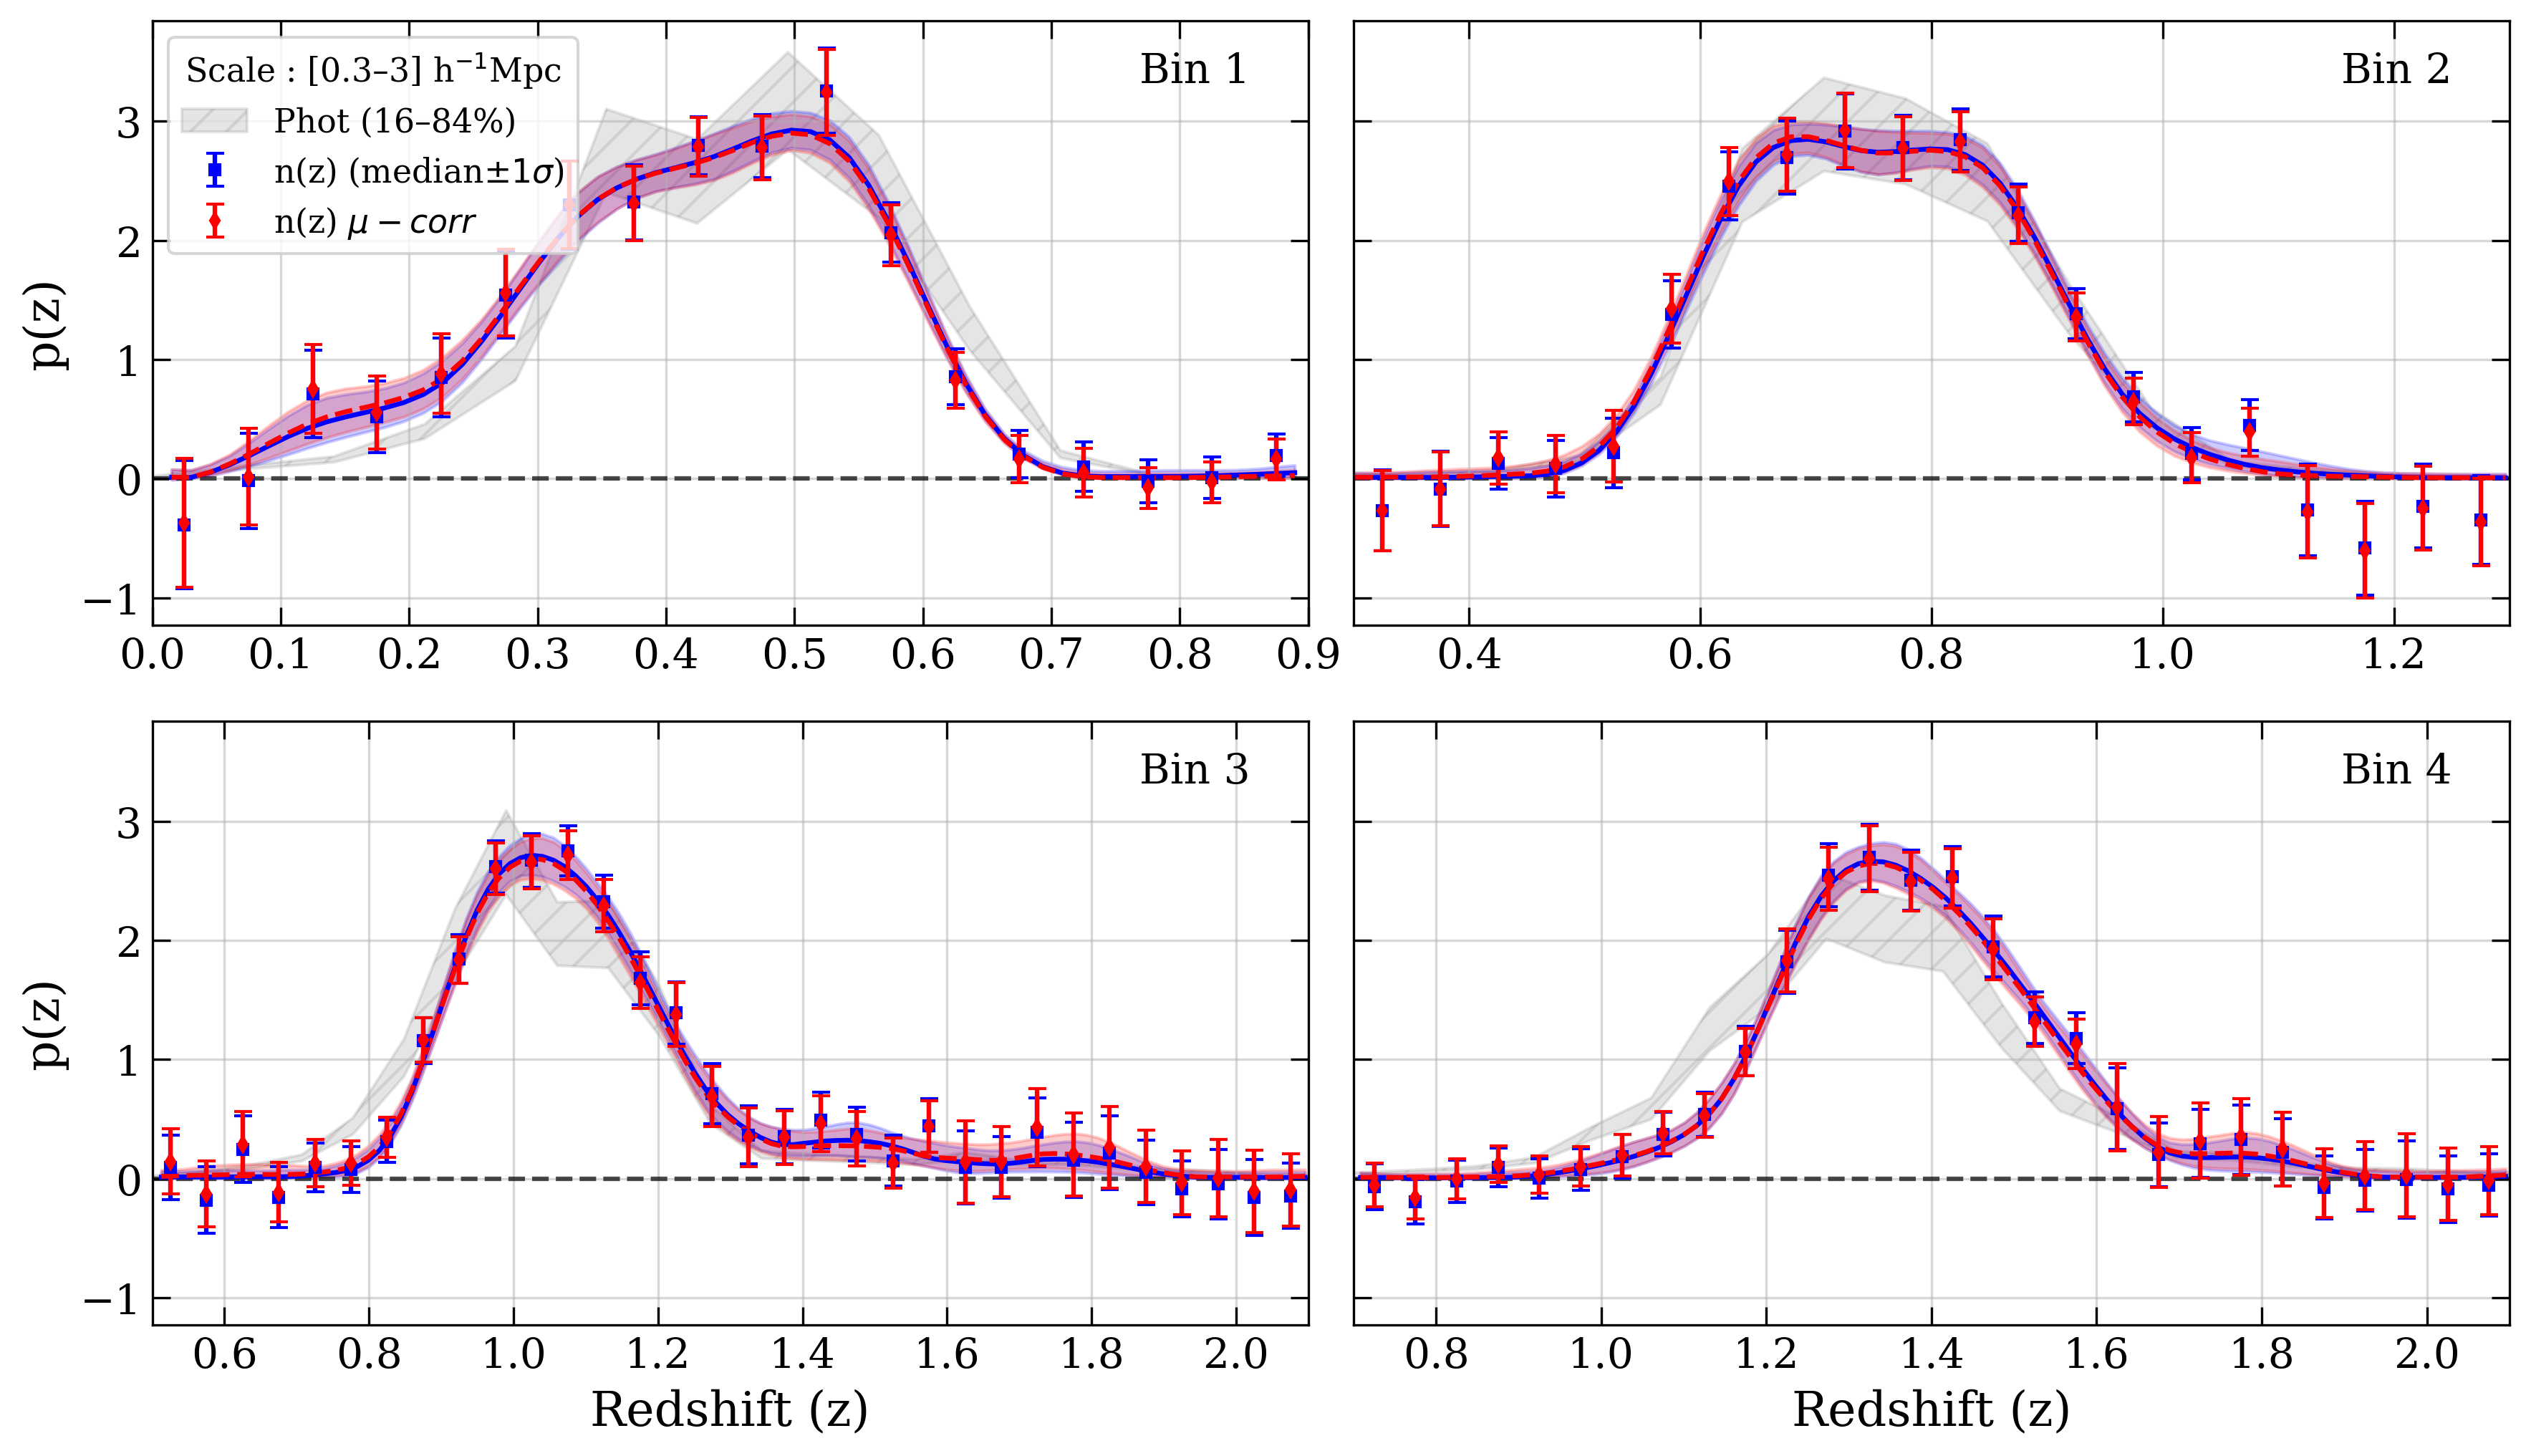](attachment:image.png)

In [10]:
print(expect)

{'1/npz_cross': array([0.44053002, 0.44785116, 0.45502359]), '1/npz_cross_mean': np.float64(0.4478162686528071), '1/npz_bs': array([0.42411499, 0.43184607, 0.43949288]), '1/npz_bs_mean': np.float64(0.43186945759223694), '1/npz_bs_bp': array([0.41815454, 0.42616472, 0.43437555]), '1/npz_bs_bp_mean': np.float64(0.42621637779756416), '1/npz_bs_bp_mag': array([0.4149503 , 0.42353688, 0.43201058]), '1/npz_bs_bp_mag_mean': np.float64(0.42348462242762824), '2/npz_cross': array([0.72534103, 0.73040027, 0.73537417]), '2/npz_cross_mean': np.float64(0.7303339889256919), '2/npz_bs': array([0.75585147, 0.76172783, 0.76804396]), '2/npz_bs_mean': np.float64(0.7619498713104751), '2/npz_bs_bp': array([0.75127297, 0.75754067, 0.76406717]), '2/npz_bs_bp_mean': np.float64(0.7576737964996374), '2/npz_bs_bp_mag': array([0.74674054, 0.75303788, 0.75941816]), '2/npz_bs_bp_mag_mean': np.float64(0.753040601089189), '3/npz_cross': array([1.13145329, 1.15452986, 1.18059018]), '3/npz_cross_mean': np.float64(1.1555

In [14]:
s_data.keys()

dict_keys(['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper'])

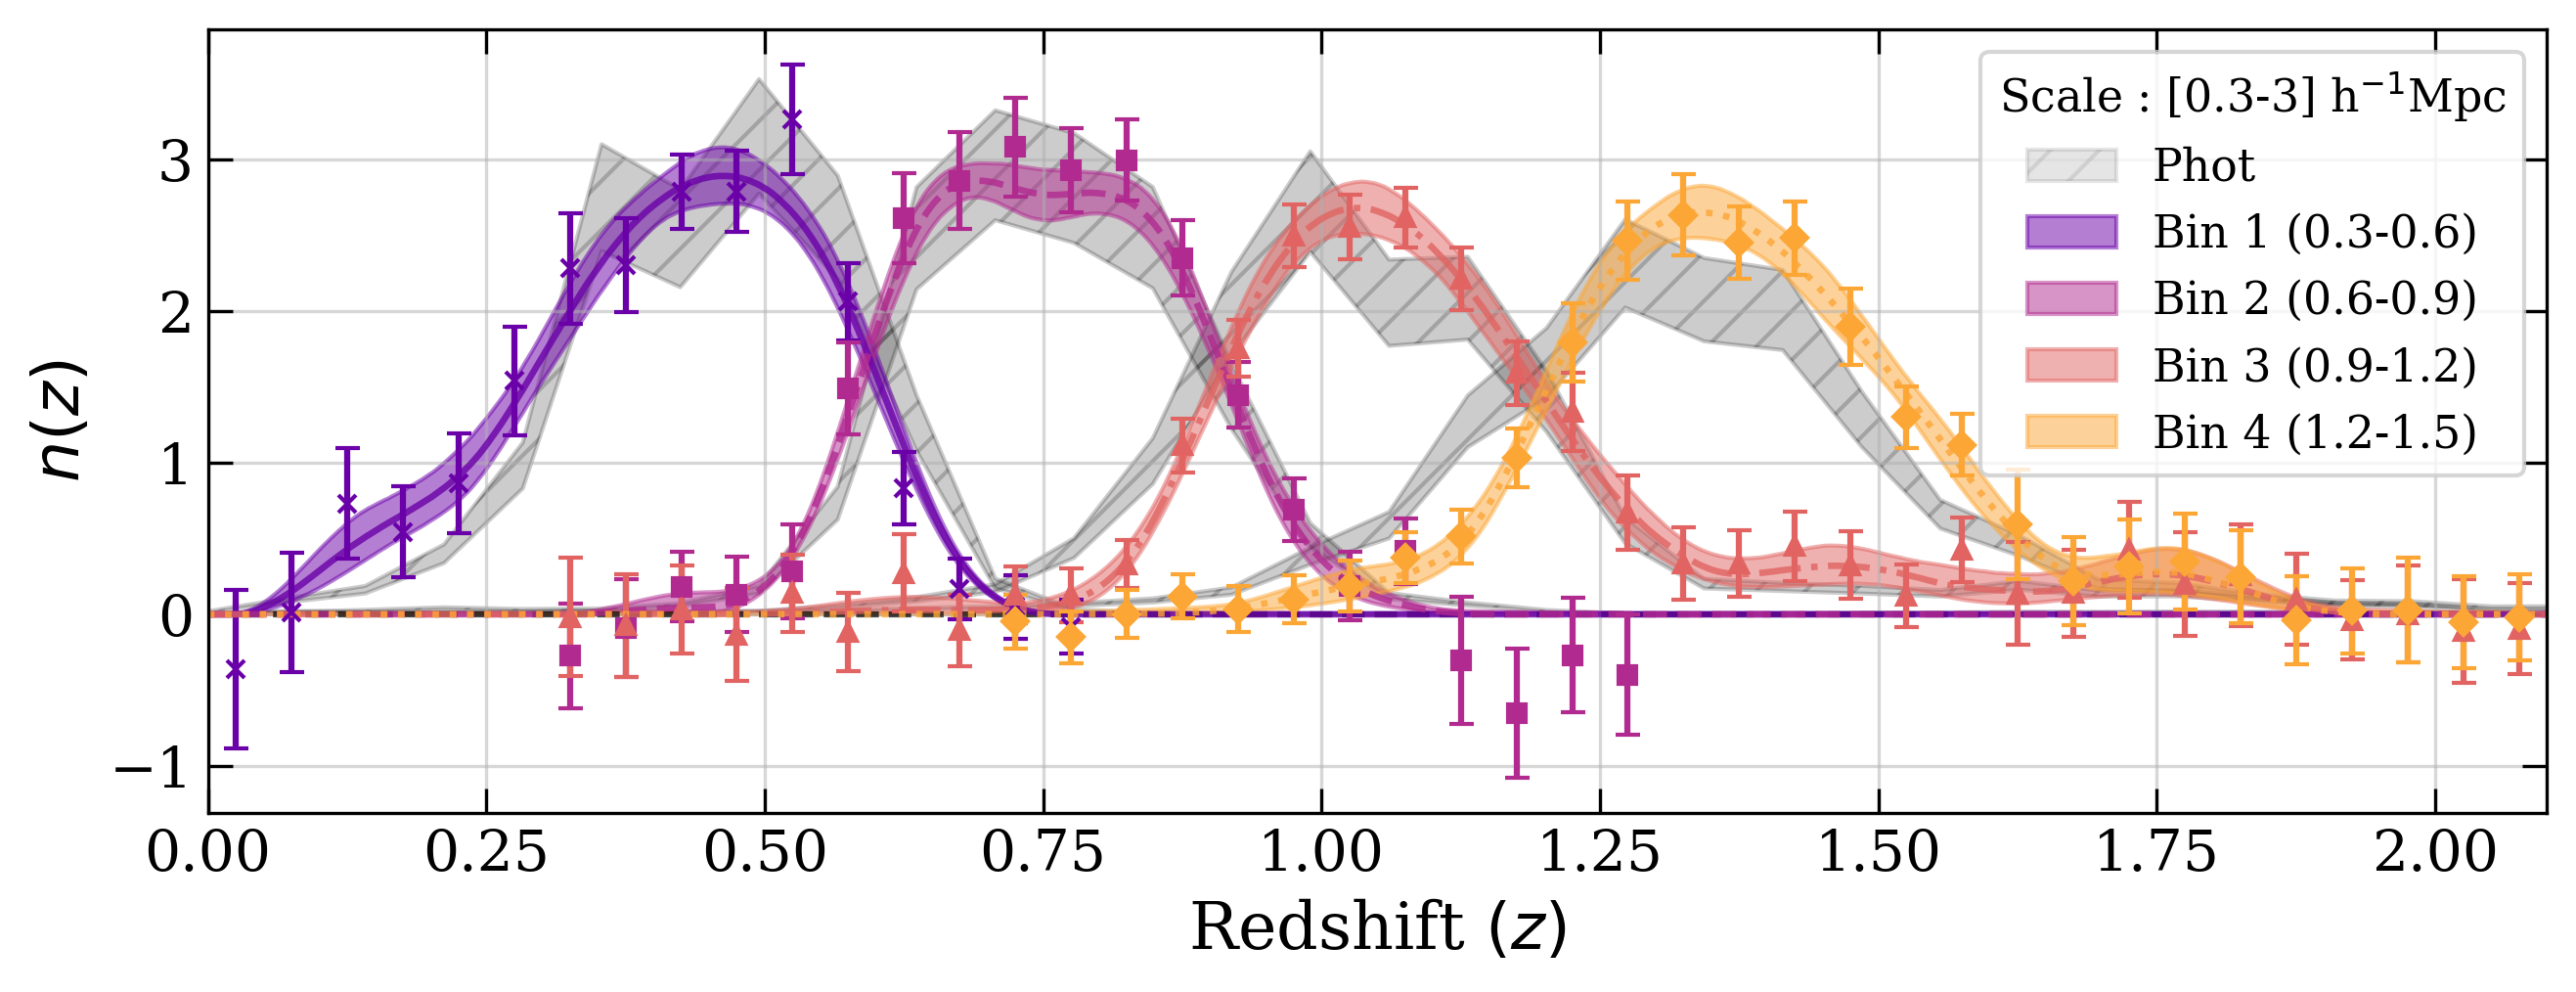

In [11]:
show_dnnz_phot = True

with pm.make_plot(name=f'all_tomo', show=True, figsize=(9, 3.6)) as (fig, ax):
    #ax.errorbar(z, npz_raw, yerr=npz_raw_err, fmt='d', color='b', capsize=3, label="No mag correction")
    #ax.errorbar(z, npz_mag, yerr=npz_mag_err, fmt='x', color='r', capsize=3, label="With mag correction")
    ax.grid(True)
    ax.axhline(0, color='black', alpha=0.7, linestyle='--')
    ax.set_xlabel(r"Redshift $(z)$",)
    ax.set_ylabel(r'$n(z)$')
    ax.set_xlim(0., 2.1)

    for tomo in [1, 2, 3, 4]:
        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color='black', 
            hatch='//',
            alpha=0.2,
            )
    z_eval_full = s_data['z']
    
    for tomo in [1, 2, 3, 4]:
        
        nz_median = s_data[f'{tomo}/nz_median']
        nz_mean = s_data[f'{tomo}/nz_mean']
        nz_lower = s_data[f'{tomo}/nz_lower']
        nz_upper = s_data[f'{tomo}/nz_upper']

        col = cmap((tomo)/5)
        ax.plot(
            z_eval_full, 
            nz_median, 
            color=col, 
            alpha=0.8,
            linewidth=1.6, 
            linestyle=linestyles[tomo-1],
            )
        ax.fill_between(
            z_eval_full, 
            nz_lower, 
            nz_upper, 
            color=col, 
            alpha=0.5, 
            )
        
        z_data = data[f'{tomo}/npz_bs_bp_mag_z']
        npz_data = data[f'{tomo}/npz_bs_bp_mag']
        npz_data_err = data[f'{tomo}/npz_bs_bp_mag_err']
        mask_data = (z_data > bounds[str(tomo)][0]) & (z_data < bounds[str(tomo)][1])
        
        ax.errorbar(z_data[mask_data], npz_data[mask_data], yerr=npz_data_err[mask_data], fmt=markers[tomo-1], color=col, capsize=3, ms=4.5, alpha=1)
            
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = []
        legend_elements.append(
            Patch(
                facecolor='gray',
                edgecolor='gray',
                alpha=0.2,
                hatch='//',
                label="Phot"
            )
        )
        for tomo in [1, 2, 3, 4]:
            col = cmap((tomo)/5)
            legend_elements.append(
                Patch(
                    facecolor=col,
                    edgecolor=col,
                    alpha=0.5,
                    label=f'Bin {tomo} ({tomo*0.3:.1f}-{(tomo+1)*0.3:.1f})'
                )
            )
        ax.legend(
            handles=legend_elements,
            loc='upper right',
            frameon=True,
            fontsize=11,
            title=f'Scale : [0.3-3] '+r'h$^{-1}$Mpc',
            title_fontsize=11
        )
    #ax.legend(title=f'Bin {tomo}\nScale : [0.3-3] '+r'h$^{-1}$Mpc', loc='upper right')

Bin 1 [n(z)]: 16th=0.415, median=0.424, 84th=0.434 : 0.424 (+0.009, -0.009)
Bin 2 [n(z)]: 16th=0.752, median=0.759, 84th=0.767 : 0.759 (+0.008, -0.007)
Bin 3 [n(z)]: 16th=1.099, median=1.118, 84th=1.140 : 1.118 (+0.022, -0.020)
Bin 4 [n(z)]: 16th=1.365, median=1.377, 84th=1.391 : 1.377 (+0.014, -0.012)
Bin 1 [n(z) $\mu$-corr]: 16th=0.4116, median=0.4208, 84th=0.4296 : 0.421 (+0.009, -0.009)
Bin 2 [n(z) $\mu$-corr]: 16th=0.7471, median=0.7545, 84th=0.7623 : 0.755 (+0.008, -0.007)
Bin 3 [n(z) $\mu$-corr]: 16th=1.0986, median=1.1215, 84th=1.1455 : 1.121 (+0.024, -0.023)
Bin 4 [n(z) $\mu$-corr]: 16th=1.3650, median=1.3789, 84th=1.3935 : 1.379 (+0.015, -0.014)
Bin 1 [n(z) DNNz]: 16th=0.4563, median=0.4618, 84th=0.4673 : 0.462 (+0.005, -0.005)
Bin 2 [n(z) DNNz]: 16th=0.7608, median=0.7662, 84th=0.7715 : 0.766 (+0.005, -0.005)
Bin 3 [n(z) DNNz]: 16th=1.0772, median=1.0835, 84th=1.0899 : 1.083 (+0.006, -0.006)
Bin 4 [n(z) DNNz]: 16th=1.3242, median=1.3300, 84th=1.3359 : 1.330 (+0.006, -0.006) 
with bounds

without bounds :
Bin 1 [n(z)]: 16th=0.439, median=0.457, 84th=0.479 : 0.457 (+0.022, -0.018)
Bin 2 [n(z)]: 16th=0.734, median=0.750, 84th=0.763 : 0.750 (+0.014, -0.016)
Bin 3 [n(z)]: 16th=1.110, median=1.135, 84th=1.164 : 1.135 (+0.029, -0.025)
Bin 4 [n(z)]: 16th=1.362, median=1.385, 84th=1.407 : 1.385 (+0.022, -0.023)
Bin 1 [n(z) $\mu$-corr]: 16th=0.4325, median=0.4493, 84th=0.4698 : 0.449 (+0.021, -0.017)
Bin 2 [n(z) $\mu$-corr]: 16th=0.7287, median=0.7442, 84th=0.7576 : 0.744 (+0.013, -0.016)
Bin 3 [n(z) $\mu$-corr]: 16th=1.1172, median=1.1471, 84th=1.1817 : 1.147 (+0.035, -0.030)
Bin 4 [n(z) $\mu$-corr]: 16th=1.3661, median=1.3910, 84th=1.4173 : 1.391 (+0.026, -0.025)
Bin 1 [n(z) DNNz]: 16th=0.4565, median=0.4619, 84th=0.4673 : 0.462 (+0.005, -0.005)
Bin 2 [n(z) DNNz]: 16th=0.7607, median=0.7663, 84th=0.7718 : 0.766 (+0.006, -0.006)
Bin 3 [n(z) DNNz]: 16th=1.0773, median=1.0836, 84th=1.0898 : 1.084 (+0.006, -0.006)
Bin 4 [n(z) DNNz]: 16th=1.3243, median=1.3301, 84th=1.3361 : 1.330 (+0.006, -0.006)

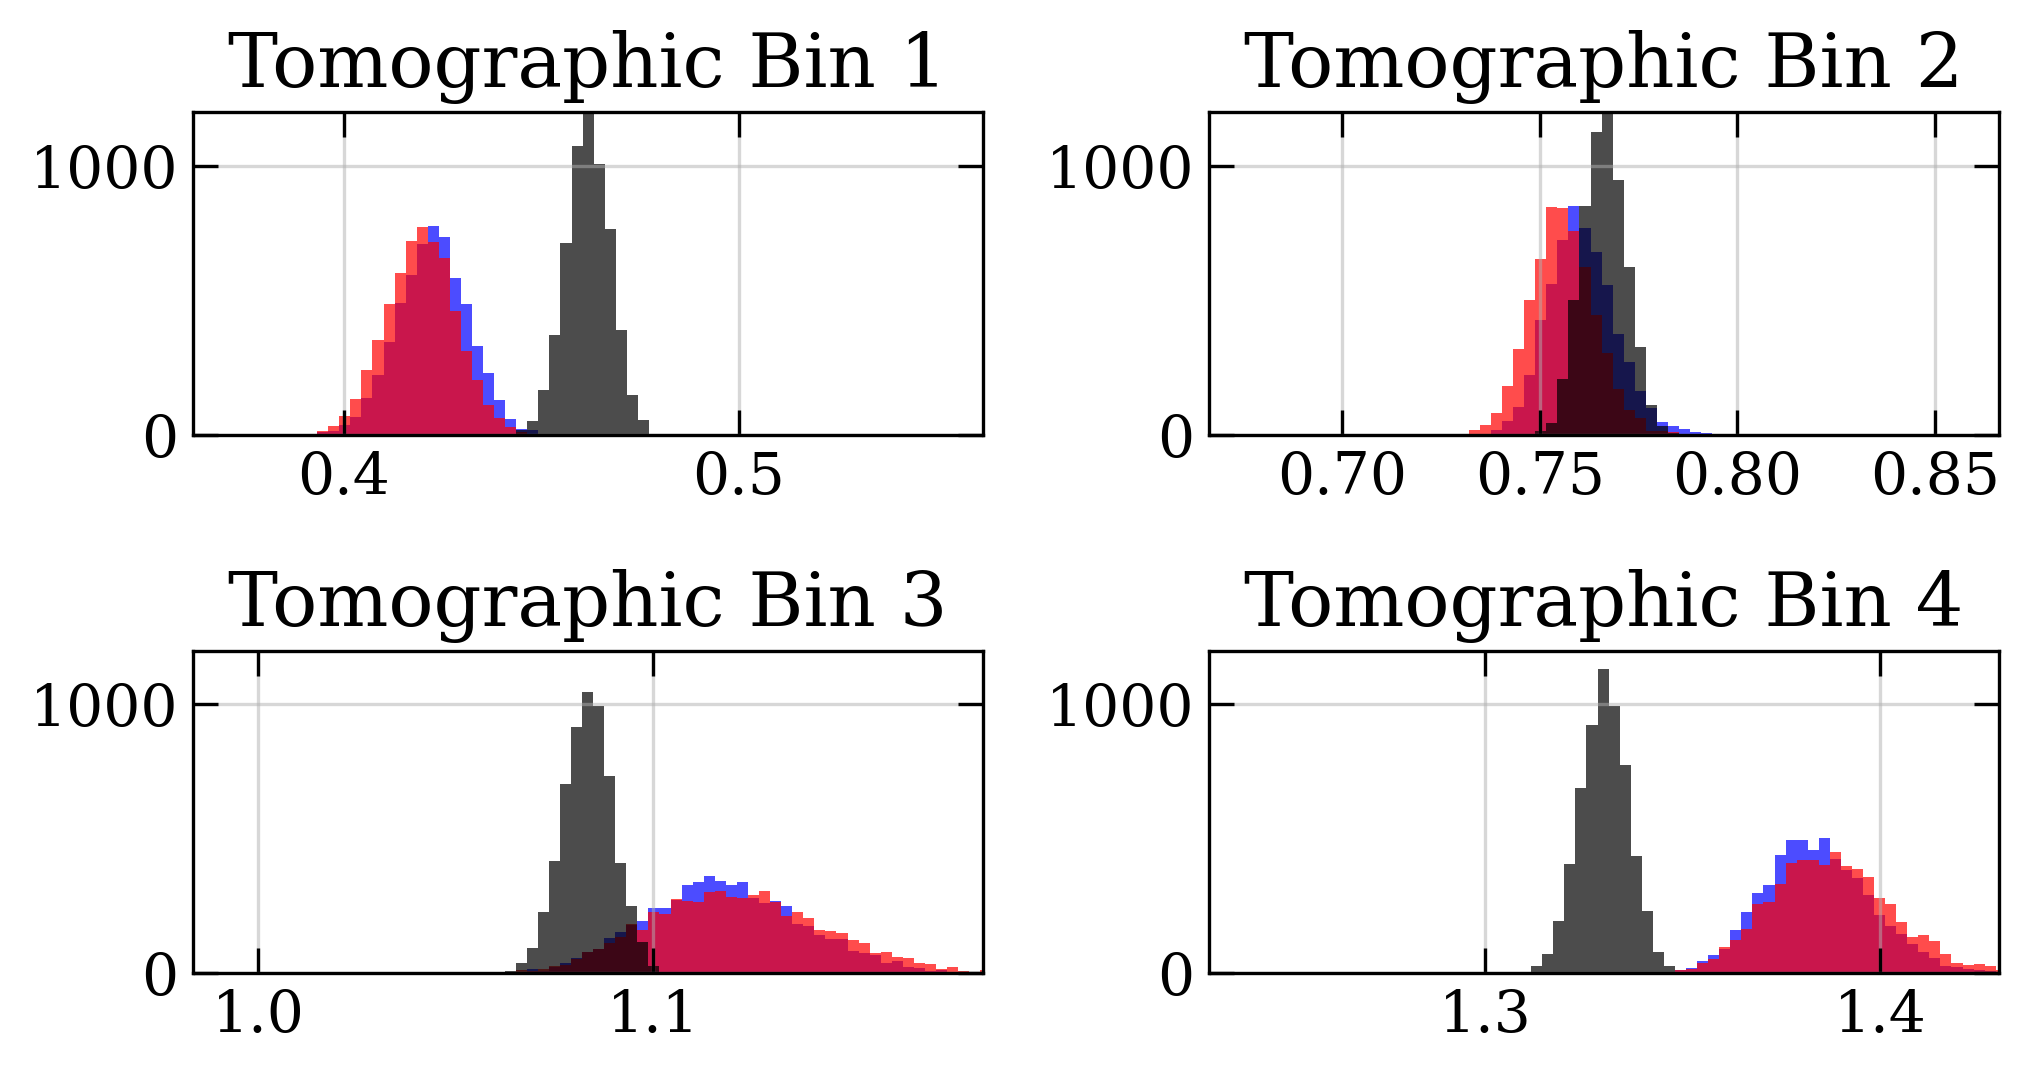

In [13]:
%pip install dill
import dill
save_splines = Path('splines')
save_splines.mkdir(exist_ok=True)
with open(save_splines / f'spline_raw_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_raw_1, f)
with open(save_splines / f'spline_mag_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_mag_1, f)

Note: you may need to restart the kernel to use updated packages.
